# 02 - Preprocesamiento, entrenamiento y evaluación

Este notebook usa el esquema actual de producción: `valuation_usd` como target y las features `year_founded`, `funding_usd`, `company_age`, `industry`, `country` y `continent`, con variables derivadas del pipeline.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if (ROOT / "backend").exists():
    BACKEND = ROOT / "backend"
else:
    BACKEND = ROOT

if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import load_config, resolve_path
from src.data.load import (
    build_and_save_processed_dataset,
    build_features,
    get_feature_columns,
    load_processed_dataset,
    load_raw_dataset,
    prepare_modeling_frame,
)

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="Set2")
config = load_config()
feature_cols = get_feature_columns()
target_col = config["project"]["target"]
print(f"Backend path: {BACKEND}")
print(f"Target actual: {target_col}")
print(f"Features actuales: {feature_cols}")


Backend path: C:\Users\usuario\Desktop\ProjectsF5\proyecto4-grupo4\backend
Target actual: valuation_usd
Features actuales: ['year_founded', 'log_funding_usd', 'funding_velocity', 'funding_vs_industry', 'company_age', 'industry', 'country', 'continent']


## 1. Dataset de modelado

Cargamos el dataset procesado y construimos `X` e `y` con las mismas funciones que usa el backend.


In [2]:
processed_path = build_and_save_processed_dataset()
featured = load_processed_dataset()
X, y = prepare_modeling_frame(featured)

print(f"Dataset procesado: {processed_path}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
display(X.head())
display(y.head().to_frame(target_col))


Dataset procesado: C:\Users\usuario\Desktop\ProjectsF5\proyecto4-grupo4\backend\data\processed\dataset.pkl
X shape: (1062, 8)
y shape: (1062,)


,year_founded,log_funding_usd,funding_velocity,funding_vs_industry,company_age,industry,country,continent
0,2012,22.802707,5.714286e+08,25.236593,14,Artificial intelligence,China,Asia
1,2002,22.669176,2.916667e+08,17.676768,24,Other,United States,North America
2,2008,21.416413,1.111111e+08,4.246285,18,E-commerce & direct-to-consumer,China,Asia
3,2010,21.416413,1.250000e+08,5.405405,16,Fintech,United States,North America
4,2005,22.109560,1.904762e+08,10.810811,21,Fintech,Other,Europe


,valuation_usd
0,1.800000e+11
1,1.000000e+11
2,1.000000e+11
3,9.500000e+10
4,4.600000e+10


## 2. Preprocesamiento actual

El pipeline aplica imputación y escalado a variables numéricas, y OneHotEncoder a variables categóricas.


In [3]:
from src.data.preprocess import build_preprocessor

preprocessor = build_preprocessor()
Xt = preprocessor.fit_transform(X)
print(preprocessor)
print(f"Matriz transformada: {Xt.shape}")
print(f"NaN en matriz transformada: {np.isnan(Xt.toarray()).sum() if hasattr(Xt, 'toarray') else np.isnan(Xt).sum()}")


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year_founded', 'log_funding_usd',
                                  'funding_velocity', 'funding_vs_industry',
                                  'company_age']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['industry', 'country', 'continent'])])
Matriz transformada: (1062, 35)
NaN en matriz transformada: 0


## 3. Comparación de modelos

Comparamos Ridge, Random Forest y Gradient Boosting. El entrenamiento usa transformación logarítmica del target y las métricas se reportan de vuelta en USD absolutos.


In [4]:
from src.models.train import train_and_evaluate

models = ["ridge", "random_forest", "gradient_boosting"]
results = []
reports = {}

for model_name in models:
    trained = train_and_evaluate(model_name)
    report = trained["report"]
    reports[model_name] = report
    results.append({
        "requested_model": model_name,
        "selected_model": report["model_type"],
        "rmse_val_b_usd": report["validation"]["rmse"] / 1e9,
        "mae_val_b_usd": report["validation"]["mae"] / 1e9,
        "r2_val": report["validation"]["r2"],
        "cv_r2_mean": report["cross_validation"]["cv_r2_mean"],
        "overfitting_gap_pct": report["overfitting"]["max_gap_pct"],
        "within_limit": report["overfitting"]["within_limit"],
    })

comparison = pd.DataFrame(results).sort_values("r2_val", ascending=False)
comparison


,requested_model,selected_model,rmse_val_b_usd,mae_val_b_usd,r2_val,cv_r2_mean,overfitting_gap_pct,within_limit
2,gradient_boosting,gradient_boosting,6.395914,1.684307,0.222159,0.275694,0.000000,True
0,ridge,ridge,6.909333,1.901669,0.092267,-146512.179526,0.000000,True
1,random_forest,dummy,7.366018,2.126761,-0.031695,-0.044231,7.689016,False


## 4. Métricas del modelo guardado

El artefacto versionado en `models/best_model.joblib` corresponde al mejor modelo actual. Estas métricas quedan disponibles para revisión sin volver a entrenar.


In [5]:
metrics_path = resolve_path(config["paths"]["metrics_file"])
model_path = resolve_path(config["paths"]["model_file"])
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))

print(f"Modelo guardado: {model_path}")
print(f"Métricas guardadas: {metrics_path}")
summary = pd.DataFrame([
    {"split": "train", **metrics["train"]},
    {"split": "validation", **metrics["validation"]},
])
summary[["rmse", "mae"]] = summary[["rmse", "mae"]] / 1e9
summary = summary.rename(columns={"rmse": "rmse_b_usd", "mae": "mae_b_usd", "r2": "r2"})
display(summary)
display(pd.DataFrame([metrics["overfitting"]]))
display(pd.DataFrame([metrics["cross_validation"]]))


Modelo guardado: C:\Users\usuario\Desktop\ProjectsF5\proyecto4-grupo4\backend\models\best_model.joblib
Métricas guardadas: C:\Users\usuario\Desktop\ProjectsF5\proyecto4-grupo4\backend\models\metrics.json


,split,rmse_b_usd,mae_b_usd,r2
0,train,7.853465,1.824465,0.219776
1,validation,6.401795,1.684872,0.220727


,mae_gap_pct,rmse_gap_pct,r2_gap_pct,max_gap_pct,within_limit
0,0.0,0.0,0.0,0.0,True


,cv_r2_mean,cv_r2_std
0,0.275695,0.118172


## 5. Predicción vs valor real y análisis de residuos

Estos gráficos permiten evaluar sesgos, dispersión del error y comportamiento en la cola alta del target.


{'rmse': 6.40179512433019, 'mae': 1.6848716612328603, 'r2': 0.220727414843099}


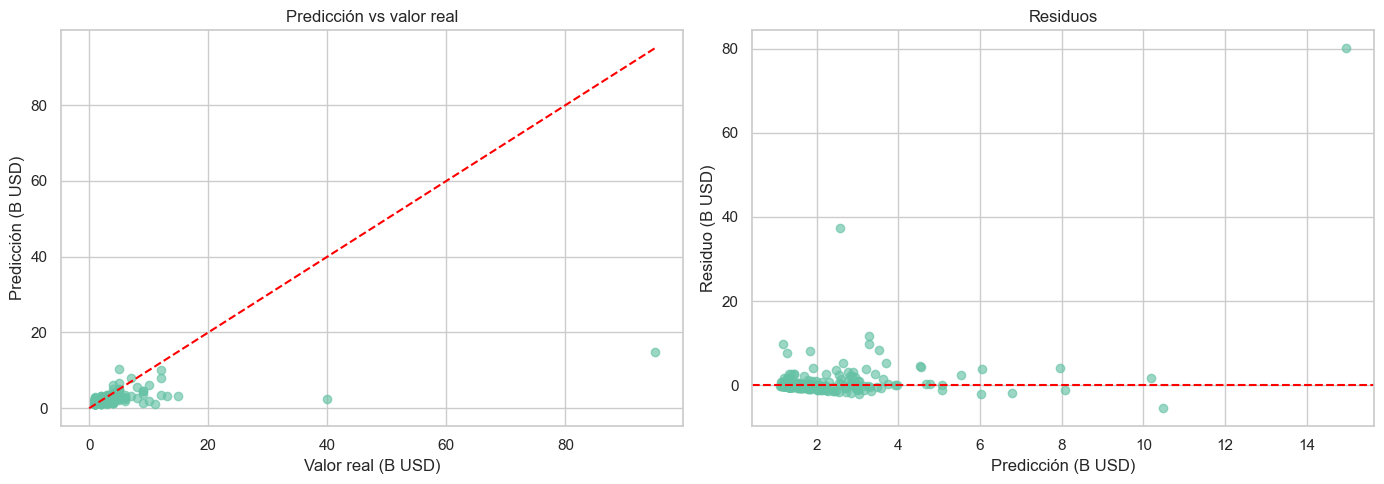

In [6]:
from sklearn.model_selection import train_test_split
from src.models.train import predict_absolute, compute_metrics

model = joblib.load(model_path)
y_bins = pd.qcut(y, q=5, duplicates="drop")
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=config["training"]["test_size"],
    random_state=config["project"]["random_state"],
    stratify=y_bins,
)

y_pred = predict_absolute(model, X_val)
val_metrics = compute_metrics(y_val.to_numpy(), y_pred).to_dict()
print({k: (v / 1e9 if k in ["rmse", "mae"] else v) for k, v in val_metrics.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_val / 1e9, y_pred / 1e9, alpha=0.65)
limit = max((y_val / 1e9).max(), (y_pred / 1e9).max())
axes[0].plot([0, limit], [0, limit], "--", color="red")
axes[0].set_title("Predicción vs valor real")
axes[0].set_xlabel("Valor real (B USD)")
axes[0].set_ylabel("Predicción (B USD)")

residuals = y_val.to_numpy() - y_pred
axes[1].scatter(y_pred / 1e9, residuals / 1e9, alpha=0.65)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuos")
axes[1].set_xlabel("Predicción (B USD)")
axes[1].set_ylabel("Residuo (B USD)")
plt.tight_layout()
plt.show()


## 6. Importancia de variables

La importancia por permutación indica qué columnas originales aportan más señal al pipeline completo.


,feature,importance
3,funding_vs_industry,4.446352e-11
2,funding_velocity,9.021395e-12
1,log_funding_usd,3.428591e-12
7,continent,1.115302e-12
6,country,2.716993e-13
5,industry,2.648715e-13
4,company_age,-2.034206e-13
0,year_founded,-6.603329e-13


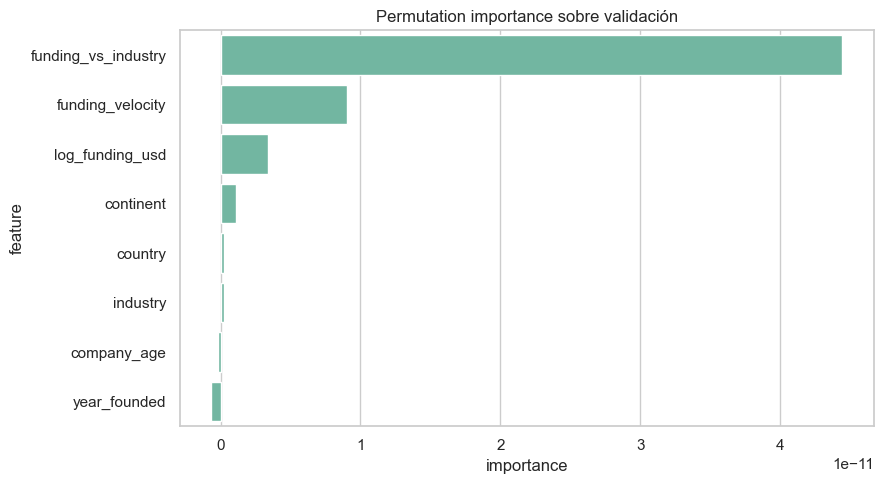

In [7]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=8,
    random_state=config["project"]["random_state"],
    n_jobs=1,
)
importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False)

display(importance)
plt.figure(figsize=(9, 5))
sns.barplot(data=importance, x="importance", y="feature")
plt.title("Permutation importance sobre validación")
plt.tight_layout()
plt.show()


## 7. Ejemplo de predicción con el contrato de la API

El frontend envía estas mismas features al endpoint `/predict`.


In [8]:
from src.data.load import get_industry_funding_medians, make_model_feature_frame
from src.models.train import predict_absolute

payload = pd.DataFrame([
    {
        "year_founded": 2015,
        "funding_usd": 50_000_000,
        "company_age": 11,
        "industry": "Fintech",
        "country": "United States",
        "continent": "North America",
    }
])

feature_frame = make_model_feature_frame(payload, industry_medians=get_industry_funding_medians())
valuation_usd = float(predict_absolute(model, feature_frame)[0])
print("Contrato equivalente al endpoint /predict")
print(f"Modelo usado: {metrics['model_type']}")
print(f"Predicción: ${valuation_usd / 1e9:.2f}B")
display(feature_frame)


Contrato equivalente al endpoint /predict
Modelo usado: gradient_boosting
Predicción: $1.34B


,year_founded,log_funding_usd,funding_velocity,funding_vs_industry,company_age,industry,country,continent
0,2015,17.727534,4.545455e+06,0.135135,11,Fintech,United States,North America


## 8. Limitaciones del modelo

- El R2 de validación es positivo, pero moderado; el modelo sirve como baseline operativo, no como valoración definitiva.
- El error absoluto medio está alrededor de miles de millones de USD, aceptable para una primera señal pero insuficiente para una decisión financiera real.
- La cola alta de valoraciones concentra errores grandes: el modelo tiende a ser conservador con empresas extremas.
- Faltan variables críticas como ingresos, crecimiento, rentabilidad, ronda de inversión, mercado objetivo y condiciones macroeconómicas.
- Antes de desplegarlo como sistema real, habría que monitorizar drift, comparar versiones con A/B testing y reentrenar solo si el nuevo modelo supera umbrales predefinidos.
